# 2. Advanced Chemistry (Dynamic Zones)

`PA3Py` was designed to be completely composition-agnostic. You can inject your own Python chemical functions and it will automatically discover the species and build the composition arrays.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../../src'))
from pa3py import PA3Py

# Load simulation
sim = PA3Py('../../tests/test_data/run_smooth_a0.001_v10')

[load_tripodpy_hdf5] Reading 100 snapshots from ../../tests/test_data/run_smooth_a0.001_v10...


## Custom Composition Function

We will define a protoplanetary disk with 4 chemical species (`silicates`, `H2O`, `CO2`, `CO`) partitioned into 4 dynamic zones.

In [2]:
from pa3py import constants as c

def chemistry_4_zones(r_cm, t_sec):
    # 1. Define the snowlines (some can migrate)
    r_h2o = 2.73 * c.AU * (max(t_sec, 1e-6) / 1e13)**(-0.5)
    r_co2 = 5.0 * c.AU
    r_co  = 12.0 * c.AU
    
    # 2. Assign relative abundances based on distance to the star
    if r_cm < r_h2o:
        return {'silicates': 1.0}                           # 100% rocky
    elif r_cm < r_co2:
        return {'silicates': 0.5, 'H2O': 0.5}               # Ice Zone
    elif r_cm < r_co:
        return {'silicates': 0.3, 'H2O': 0.3, 'CO2': 0.4}   # CO2 Zone
    else:
        return {'silicates': 0.2, 'H2O': 0.2, 'CO2': 0.3, 'CO': 0.3} # Cold Zone

# Inject our function into the engine. PA3Py will auto-detect the species.
sim.set_custom_chemistry(chemistry_4_zones)

## Running Custom Chemistry

We will place embryos in various regions and let PA3Py handle the rest.

In [3]:
# Embryos in the rocky, ice, CO2, and CO zones
results = sim.run_growth([2.0, 4.0, 8.0, 15.0])


---------------------------------------------------------------------------------
  r [AU]  M_tot [ME]  M_iso [ME]   f_CO[%]  f_silicates[%]  f_CO2[%]  f_H2O[%]
---------------------------------------------------------------------------------
    2.00        0.164         6.65       0.0            87.7       0.0      12.3
    4.00        0.306        11.19       0.0            63.8       0.0      36.2
    8.00        0.123        18.82       0.0            39.7      34.4      25.8
   15.00        0.001        30.15       6.5            82.7       6.5       4.3
---------------------------------------------------------------------------------



## Visualizing Multi-Species Composition

With more than two species, `plot_species_fraction` accepts a list of species (or `None` for **all** tracked species). With several embryos, the color identifies the embryo and the line style identifies the species; for a single embryo, each species gets its own color.

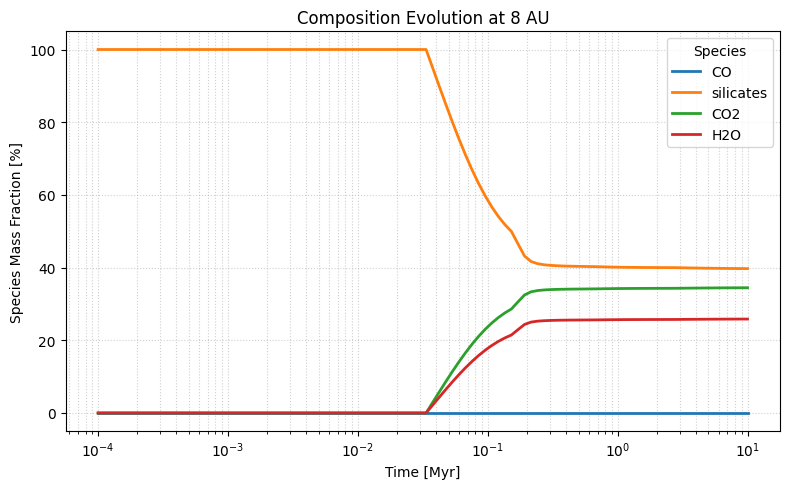

In [4]:
# Full composition history of the embryo in the CO2 zone (single embryo → color per species)
fig, ax = sim.plot_species_fraction(results, species=None, embryos=[8.0])